# PolypharmaSafe — Notebook de lecture, synthèse et préparation au déploiement

Ce notebook a été réorganisé pour qu'une personne puisse comprendre le projet **en lisant uniquement les cellules Markdown**


  

# 1. Objectif du projet

Le projet cherche à prédire si **deux médicaments** peuvent présenter une **interaction médicamenteuse (DDI)**, puis à rendre cette prédiction **interprétable**.

L'idée finale n'est pas seulement de produire un score binaire, mais de fournir une **fiche d'alerte exploitable** pour un pharmacien, un clinicien ou une application de dépistage de risques.**bold text**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rdkit -q
!pip install xgboost shap -q
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 44.2 MB/s eta 0:00:00


# 2. Jeux de données utilisés



1. **DrugBank DDI** : interactions documentées entre paires de médicaments.
2. **TWOSIDES** : signaux de pharmacovigilance observés sur des co-prescriptions.
3. **DrugBank SMILES** : représentation chimique textuelle des molécules.

Cette combinaison est pertinente :
- DrugBank apporte des interactions mieux structurées et souvent plus cliniquement décrites.
- TWOSIDES élargit la couverture via des signaux réels.
- Les SMILES permettent de calculer des descripteurs moléculaires à partir de la structure.

In [ ]:

import subprocess, sys
try:
    import rdkit  # noqa
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "rdkit", "--quiet"])

# ══════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              average_precision_score, classification_report,
                              confusion_matrix, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier

import joblib

# ══════════════════════════════════════════════════════
# REPRODUCTIBILITÉ
# ══════════════════════════════════════════════════════
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_style("whitegrid")
PALETTE = {"pos": "#4C72B0", "neg": "#DD8452", "third": "#55A868", "warm": "#4C72B0", "cold": "#C44E52"}

# ══════════════════════════════════════════════════════
# CHEMINS (à adapter si l'arborescence Kaggle diffère)
# ══════════════════════════════════════════════════════
DATA_DIR      = "/content/drive/MyDrive/Colab_Notebooks/pfm_ml_Explainable_DDI_Alert_System/1/data"
DDI_PATH      = f"{DATA_DIR}/drugbank-ddi_36k.csv"
TWOSIDES_PATH = f"{DATA_DIR}/TWOSIDES_36k.csv"
SMILES_PATH   = f"{DATA_DIR}/drugbank_smiles.csv"

# ══════════════════════════════════════════════════════
# PARAMÈTRES DU PIPELINE
# ══════════════════════════════════════════════════════
FP_RADIUS = 2          # rayon Morgan (= ECFP4)
FP_BITS   = 2048        # taille du fingerprint par molécule
COLD_HOLDOUT_FRAC = 0.15   # fraction de médicaments isolés pour le test cold-start
WARM_TEST_FRAC    = 0.30   # train=70% / (val+test)=30% en warm-start
IMBALANCE_RATIO   = 10     # ratio négatifs:positifs pour l'évaluation sous déséquilibre réaliste
N_BOOTSTRAP       = 1000   # nombre de tirages pour les IC bootstrap

print("✅ Configuration chargée.")


✅ Configuration chargée.


## Chargement des données

On charge les trois fichiers et on vérifie leurs schémas (déjà confirmés lors de l'exploration initiale) :
`drugbank_id / name / cas / smiles / ...` pour les structures, `Drug1 ID / Interaction / Drug2 ID` pour les
interactions DrugBank, `drug_1_concept_name / drug_2_concept_name / ...` pour TWOSIDES.

In [ ]:
df_ddi      = pd.read_csv(DDI_PATH)
df_twosides = pd.read_csv(TWOSIDES_PATH)
df_smiles   = pd.read_csv(SMILES_PATH)

print(f"DrugBank-DDI : {df_ddi.shape}  | colonnes : {df_ddi.columns.tolist()}")
print(f"TWOSIDES     : {df_twosides.shape}  | colonnes : {df_twosides.columns.tolist()}")
print(f"SMILES       : {df_smiles.shape}  | colonnes : {df_smiles.columns.tolist()}")


DrugBank-DDI : (36000, 4)  | colonnes : ['Unnamed: 0', 'Drug1 ID', 'Interaction', 'Drug2 ID']
TWOSIDES     : (36000, 13)  | colonnes : ['drug_1_rxnorn_id', 'drug_1_concept_name', 'drug_2_rxnorm_id', 'drug_2_concept_name', 'condition_meddra_id', 'condition_concept_name', 'A', 'B', 'C', 'D', 'PRR', 'PRR_error', 'mean_reporting_frequency']
SMILES       : (8288, 10)  | colonnes : ['drugbank_id', 'name', 'cas', 'smiles', 'logP ALOGPS', 'logP ChemAxon', 'solubility ALOGPS', 'pKa (strongest acidic)', 'pKa (strongest basic)', 'description']



# 3. Nettoyage chimique et canonicalisation des SMILES

Convertit chaque SMILES vers une forme **canonique RDKit**. Cette étape est importante, car une même molécule peut être écrite sous plusieurs formes textuelles.

Ce nettoyage permet ensuite de construire deux mappings centraux :
- `id_to_smiles` : identifiant DrugBank → SMILES canonique
- `name_to_id` : nom du médicament → identifiant DrugBank

 élimine aussi les entrées invalides ou dupliquées, ce qui est une bonne pratique pour éviter des erreurs silencieuses plus loin dans le pipeline.


In [ ]:
def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except Exception:
        return None

df_smiles["smiles_canonical"] = df_smiles["smiles"].apply(canonicalize)

n_before = len(df_smiles)
df_smiles = (df_smiles
             .dropna(subset=["smiles_canonical"])
             .drop_duplicates(subset=["drugbank_id"])
             .reset_index(drop=True))
n_after = len(df_smiles)

print(f"SMILES invalides ou dupliqués supprimés : {n_before - n_after}")
print(f"Molécules valides restantes              : {n_after}")

# Mappings construits UNE SEULE FOIS, à partir des SMILES canoniques
id_to_smiles = dict(zip(df_smiles["drugbank_id"], df_smiles["smiles_canonical"]))
name_to_id   = dict(zip(df_smiles["name"].str.lower().str.strip(), df_smiles["drugbank_id"]))
valid_ids    = set(id_to_smiles.keys())

print(f" id_to_smiles : {len(id_to_smiles)} entrées")
print(f" name_to_id   : {len(name_to_id)} entrées")


[11:18:58] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[11:18:58] Explicit valence for atom # 14 N, 4, is greater than permitted
[11:18:58] Explicit valence for atom # 19 O, 2, is greater than permitted
[11:18:59] Explicit valence for atom # 6 Be, 4, is greater than permitted
[11:18:59] Unusual charge on atom 0 number of radical electrons set to zero
[11:19:01] Explicit valence for atom # 13 Be, 4, is greater than permitted
[11:19:01] Explicit valence for atom # 84 N, 4, is greater than permitted


SMILES invalides ou dupliqués supprimés : 6
Molécules valides restantes              : 8282
✅ id_to_smiles : 8282 entrées
✅ name_to_id   : 8282 entrées


# 4. Correction méthodologique majeure : unifier l'espace des identifiants

Le pipeline corrige un problème fréquent :
- DrugBank DDI est indexé par **IDs DrugBank**.
- TWOSIDES est d'abord exprimé avec des **noms de médicaments**.

Remappe donc TWOSIDES vers le même espace d'identifiants DrugBank avant de fusionner les sources. Cela évite un bug méthodologique grave où positifs et négatifs ne seraient pas décrits dans le même référentiel.

In [ ]:
def pair_key(a, b):
    # Clé canonique d'une paire, insensible à l'ordre des deux médicaments
    return tuple(sorted([a, b]))

# --- DrugBank-DDI : déjà en IDs DrugBank ---
df_ddi_ok = df_ddi.copy()
df_ddi_ok["Drug1_ID"] = df_ddi_ok["Drug1 ID"]
df_ddi_ok["Drug2_ID"] = df_ddi_ok["Drug2 ID"]
df_ddi_ok = df_ddi_ok[df_ddi_ok["Drug1_ID"].isin(valid_ids) & df_ddi_ok["Drug2_ID"].isin(valid_ids)]

ddi_pairs = {}
for r in df_ddi_ok.itertuples():
    ddi_pairs[pair_key(r.Drug1_ID, r.Drug2_ID)] = r.Interaction

print(f"Paires DrugBank-DDI valides (SMILES disponibles des deux côtés) : {len(ddi_pairs):,}")

# --- TWOSIDES : noms convertis en IDs DrugBank (même espace que ci-dessus) ---
df_tw_ok = df_twosides.copy()
df_tw_ok["Drug1_ID"] = df_tw_ok["drug_1_concept_name"].str.lower().str.strip().map(name_to_id)
df_tw_ok["Drug2_ID"] = df_tw_ok["drug_2_concept_name"].str.lower().str.strip().map(name_to_id)
df_tw_ok = df_tw_ok.dropna(subset=["Drug1_ID", "Drug2_ID"])

tw_pairs = set()
for r in df_tw_ok.itertuples():
    tw_pairs.add(pair_key(r.Drug1_ID, r.Drug2_ID))

print(f"Paires TWOSIDES mappées vers des IDs DrugBank valides            : {len(tw_pairs):,}")
print(f"Couverture TWOSIDES (paires mappées / paires totales)            : {len(df_tw_ok)/len(df_twosides)*100:.1f}%")


Paires DrugBank-DDI valides (SMILES disponibles des deux côtés) : 15,115
Paires TWOSIDES mappées vers des IDs DrugBank valides            : 11,688
Couverture TWOSIDES (paires mappées / paires totales)            : 43.4%


# 5. Construction des exemples positifs

Les positifs sont construits comme l'union des paires documentées par :
- DrugBank,
- TWOSIDES,
- ou les deux.

Chaque paire est rendue **insensible à l'ordre** grâce à une clé canonique `pair_key(a, b)`.

Cela signifie que `(A, B)` et `(B, A)` sont traités comme la même interaction, ce qui est indispensable pour un problème de DDI.

In [ ]:
known_interactions = {}  # pair_key -> set des sources qui la documentent
for k in ddi_pairs:
    known_interactions.setdefault(k, set()).add("DrugBank")
for k in tw_pairs:
    known_interactions.setdefault(k, set()).add("TWOSIDES")

rows = []
for (a, b), srcs in known_interactions.items():
    rows.append([a, id_to_smiles[a], b, id_to_smiles[b], 1, ";".join(sorted(srcs))])

df_pos = pd.DataFrame(rows, columns=["Drug1_ID", "Drug1_SMILES", "Drug2_ID", "Drug2_SMILES", "Label", "Source"])

print(f" Interactions documentées (positifs, sources fusionnées) : {len(df_pos):,}")
print(df_pos["Source"].value_counts())


✅ Interactions documentées (positifs, sources fusionnées) : 26,618
Source
DrugBank             14930
TWOSIDES             11503
DrugBank;TWOSIDES      185
Name: count, dtype: int64


# 6. Construction des vrais négatifs

Ne tire pas les négatifs au hasard sans contrôle. Il impose une règle claire :

> une paire négative doit être absente de toutes les sources connues d'interaction.

C'est une bonne décision. Dans ce type de projet, la qualité des négatifs est aussi importante que celle des positifs. Sans cette vérification, on risque d'introduire de faux négatifs et de fausser l'apprentissage.

In [ ]:
all_ids = list(valid_ids)
n_pos = len(df_pos)

def sample_negatives(n_target, exclude_keys, rng, max_factor=50):
    neg = set()
    tries, max_tries = 0, n_target * max_factor
    while len(neg) < n_target and tries < max_tries:
        a, b = rng.sample(all_ids, 2)
        k = pair_key(a, b)
        if k not in exclude_keys and k not in neg:
            neg.add(k)
        tries += 1
    return neg

neg_pairs = sample_negatives(n_pos, known_interactions, random)
print(f"Négatifs générés (équilibre 1:1 avec les positifs) : {len(neg_pairs):,}")

neg_rows = [[a, id_to_smiles[a], b, id_to_smiles[b], 0, "random_unlisted"] for a, b in neg_pairs]
df_neg = pd.DataFrame(neg_rows, columns=df_pos.columns)

df_final = (pd.concat([df_pos, df_neg], ignore_index=True)
            .sample(frac=1, random_state=SEED)
            .reset_index(drop=True))

# Vérification stricte : aucun négatif ne doit chevaucher une interaction documentée
neg_check = set(pair_key(a, b) for a, b in zip(df_final.loc[df_final.Label == 0, "Drug1_ID"],
                                                df_final.loc[df_final.Label == 0, "Drug2_ID"]))
assert len(neg_check & set(known_interactions.keys())) == 0, "FUITE : un négatif est en réalité une interaction documentée"

print(f"\n DATASET FINAL : {len(df_final):,} paires "
      f"({df_final['Label'].mean()*100:.1f}% positifs)")
print(" Vérifié : aucun négatif ne chevauche une interaction documentée (DrugBank ∪ TWOSIDES)")


Négatifs générés (équilibre 1:1 avec les positifs) : 26,618

✅ DATASET FINAL : 53,236 paires (50.0% positifs)
✅ Vérifié : aucun négatif ne chevauche une interaction documentée (DrugBank ∪ TWOSIDES)


# 7. Dataset final

Le dataset final est équilibré en **1:1** entre positifs et négatifs pour l'entraînement principal.

D'après le notebook exécuté :
- **26 618 positifs** documentés,
- **26 618 négatifs** échantillonnés,
- soit **53 236 paires** au total.

Cet équilibre simplifie l'apprentissage, mais il ne reflète pas le monde réel. Le notebook compense cela plus tard avec une évaluation sous déséquilibre réaliste.

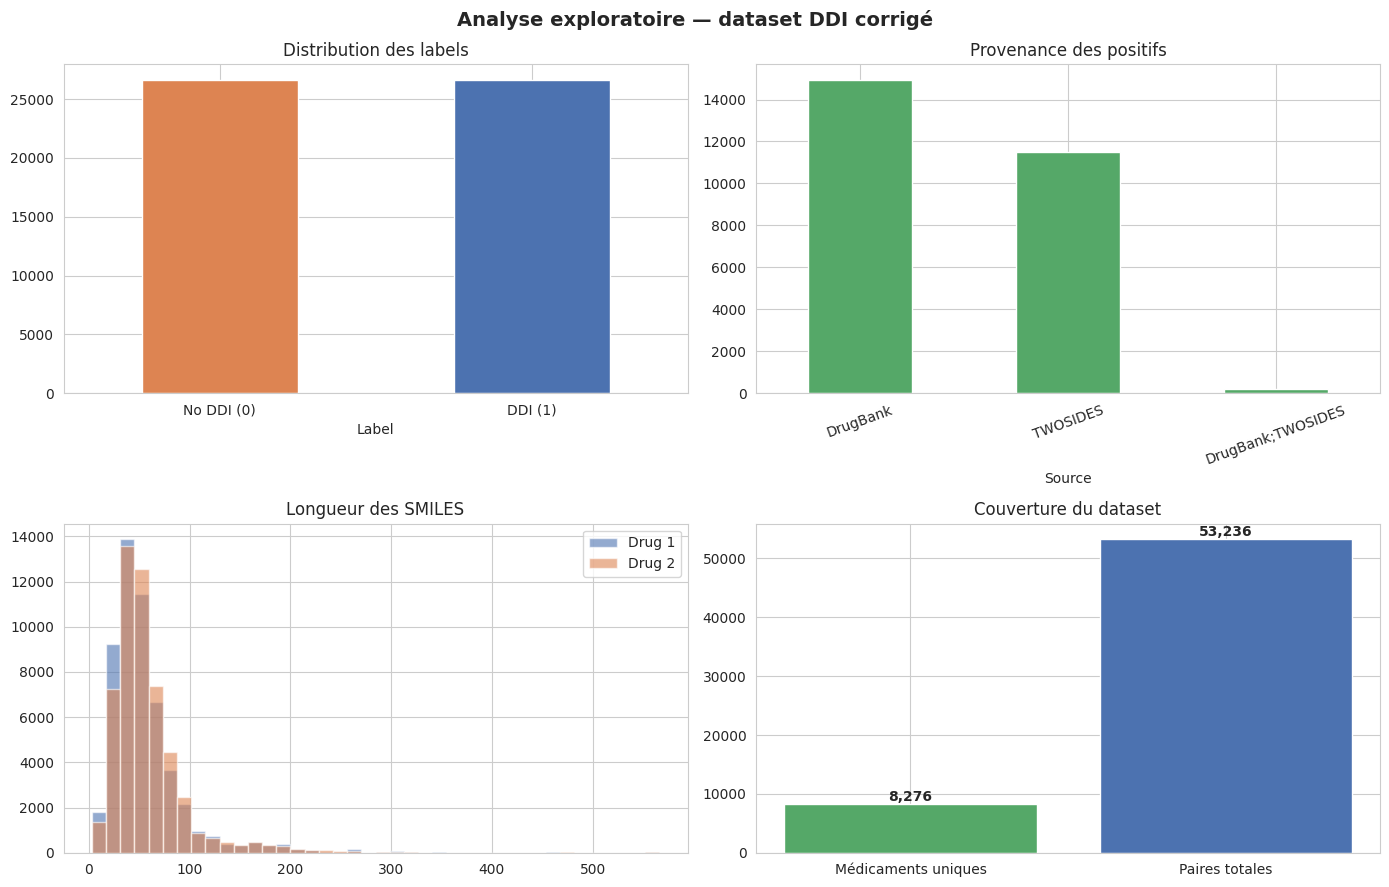

In [ ]:
df_final["len1"] = df_final["Drug1_SMILES"].str.len()
df_final["len2"] = df_final["Drug2_SMILES"].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Analyse exploratoire — dataset DDI corrigé", fontsize=14, fontweight="bold")

df_final["Label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color=[PALETTE["neg"], PALETTE["pos"]])
axes[0, 0].set_title("Distribution des labels")
axes[0, 0].set_xticklabels(["No DDI (0)", "DDI (1)"], rotation=0)

df_final.loc[df_final.Label == 1, "Source"].value_counts().plot(
    kind="bar", ax=axes[0, 1], color=PALETTE["third"])
axes[0, 1].set_title("Provenance des positifs")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].hist(df_final["len1"], bins=40, alpha=0.6, color=PALETTE["pos"], label="Drug 1")
axes[1, 0].hist(df_final["len2"], bins=40, alpha=0.6, color=PALETTE["neg"], label="Drug 2")
axes[1, 0].set_title("Longueur des SMILES")
axes[1, 0].legend()

n_unique_drugs = len(set(df_final["Drug1_ID"]) | set(df_final["Drug2_ID"]))
axes[1, 1].bar(["Médicaments uniques", "Paires totales"], [n_unique_drugs, len(df_final)],
               color=[PALETTE["third"], PALETTE["pos"]])
axes[1, 1].set_title("Couverture du dataset")
for i, v in enumerate([n_unique_drugs, len(df_final)]):
    axes[1, 1].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


## 8. Deux protocoles d'évaluation : warm-start et cold-start
Séparer deux scénarios :

### Warm-start
Split classique train / validation / test par paires.

### Cold-start
On met de côté des **médicaments jamais vus à l'entraînement**. Cela teste mieux la capacité du modèle à généraliser à de nouvelles molécules.

Split stratifié classique : 70% train / 15% validation / 15% test. Une paire donnée n'apparaît que dans un
seul des trois sous-ensembles.

In [ ]:
idx_train, idx_tmp = train_test_split(
    df_final.index, test_size=WARM_TEST_FRAC, random_state=SEED, stratify=df_final["Label"])
idx_val, idx_test = train_test_split(
    idx_tmp, test_size=0.5, random_state=SEED, stratify=df_final.loc[idx_tmp, "Label"])

def pairset(df, idx):
    return set(pair_key(a, b) for a, b in zip(df.loc[idx, "Drug1_ID"], df.loc[idx, "Drug2_ID"]))

p_train, p_val, p_test = pairset(df_final, idx_train), pairset(df_final, idx_val), pairset(df_final, idx_test)

assert not (p_train & p_val), "Fuite Train/Val"
assert not (p_train & p_test), "Fuite Train/Test"
assert not (p_val & p_test), "Fuite Val/Test"

print(f"Train      : {len(idx_train):,} paires")
print(f"Validation : {len(idx_val):,} paires")
print(f"Test       : {len(idx_test):,} paires")
print(" Aucune fuite de paires entre les splits (warm-start)")


Train      : 37,265 paires
Validation : 7,985 paires
Test       : 7,986 paires
✅ Aucune fuite de paires entre les splits (warm-start)


# 9. Contrôle de similarité structurale

 Remarque un résultat contre-intuitif : le **cold-start** performe mieux que le **warm-start**.

Plutôt que d'ignorer ce point, il teste une hypothèse utile : peut-être que les molécules du cold-start ont quand même des **analogues structuraux proches** dans le train.

Cette vérification par similarité **Tanimoto** montre une vraie réflexion méthodologique : un cold-start n'est pas forcément une vraie extrapolation hors distribution.

In [ ]:
all_drugs_in_final = sorted(set(df_final["Drug1_ID"]) | set(df_final["Drug2_ID"]))
n_holdout = max(1, int(COLD_HOLDOUT_FRAC * len(all_drugs_in_final)))
holdout_drugs = set(random.sample(all_drugs_in_final, n_holdout))

cold_mask = df_final.apply(
    lambda r: (r["Drug1_ID"] in holdout_drugs) or (r["Drug2_ID"] in holdout_drugs), axis=1)

df_cold_test  = df_final[cold_mask].reset_index(drop=True)
df_warm_pool  = df_final[~cold_mask].reset_index(drop=True)  # médicaments holdout totalement absents

assert len(set(df_warm_pool["Drug1_ID"]) & holdout_drugs) == 0
assert len(set(df_warm_pool["Drug2_ID"]) & holdout_drugs) == 0

print(f"Médicaments isolés (jamais vus à l'entraînement) : {n_holdout} / {len(all_drugs_in_final)}")
print(f"Paires test cold-start                           : {len(df_cold_test):,}")
print(" Aucun médicament isolé ne fuite dans le pool d'entraînement cold-start")


Médicaments isolés (jamais vus à l'entraînement) : 1241 / 8276
Paires test cold-start                           : 14,503
✅ Aucun médicament isolé ne fuite dans le pool d'entraînement cold-start


# A. Tanimoto :
**Pourquoi**  :AUC cold-start (0.98) est plus élevée que ton AUC warm-start (0.96), ce qui est contre-intuitif.
Une hypothèse plausible est que les médicaments isolés au hasard ont des fingerprints structurellement très
proches de molécules déjà vues à l'entraînement (analogues structuraux), ce qui réintroduit du signal malgré
l'absence de fuite d'identifiants stricte. Cette cellule vérifie cette hypothèse.

Calcul des similarités max holdout → pool train (peut prendre 1-2 min)...


Streaming output truncated to the last 5000 lines.
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:20:21] DEPRECATION WARNING: please use MorganGenerator
[11:2

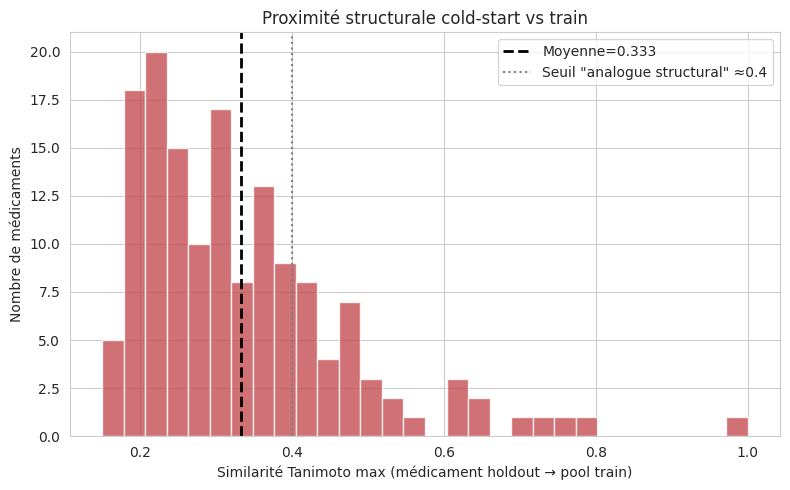


Similarité Tanimoto max moyenne : 0.3331
Médicaments holdout avec un analogue proche (Tanimoto≥0.4) dans le train : 24.7%

✅ Les médicaments holdout sont structurellement distincts du pool train.
   L'AUC élevée en cold-start reflète une vraie capacité de généralisation, pas un artefact de similarité.


In [ ]:
# ══════════════════════════════════════════════════════
# A. Tanimoto — médicaments holdout (cold) vs médicaments train
# ══════════════════════════════════════════════════════
from rdkit import DataStructs
from rdkit.Chem import AllChem

def tanimoto_smiles(s1, s2):
    m1, m2 = Chem.MolFromSmiles(s1), Chem.MolFromSmiles(s2)
    if m1 is None or m2 is None: return np.nan
    fp1 = AllChem.GetMorganFingerprintAsBitVect(m1, FP_RADIUS, nBits=FP_BITS)
    fp2 = AllChem.GetMorganFingerprintAsBitVect(m2, FP_RADIUS, nBits=FP_BITS)
    return DataStructs.TanimotoSimilarity(fp1, fp2)

# Médicaments du pool d'entraînement (warm) vs médicaments isolés (cold holdout)
train_drugs_ids = sorted(set(df_warm_pool['Drug1_ID']) | set(df_warm_pool['Drug2_ID']))

# Pour chaque médicament holdout, similarité max avec le pool d'entraînement
rng_tan = random.Random(SEED)
sample_holdout = rng_tan.sample(sorted(holdout_drugs), min(150, len(holdout_drugs)))
sample_train   = rng_tan.sample(train_drugs_ids, min(300, len(train_drugs_ids)))

print('Calcul des similarités max holdout → pool train (peut prendre 1-2 min)...')
max_sims = []
for h_id in sample_holdout:
    h_smiles = id_to_smiles[h_id]
    sims = [tanimoto_smiles(h_smiles, id_to_smiles[t_id]) for t_id in sample_train]
    sims = [s for s in sims if not np.isnan(s)]
    if sims:
        max_sims.append(max(sims))

max_sims = np.array(max_sims)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(max_sims, bins=30, color=PALETTE['cold'], edgecolor='white', alpha=0.8)
ax.axvline(max_sims.mean(), color='black', linestyle='--', linewidth=2,
           label=f'Moyenne={max_sims.mean():.3f}')
ax.axvline(0.4, color='gray', linestyle=':', linewidth=1.5, label='Seuil "analogue structural" ≈0.4')
ax.set(xlabel='Similarité Tanimoto max (médicament holdout → pool train)',
       ylabel='Nombre de médicaments',
       title='Proximité structurale cold-start vs train')
ax.legend()
plt.tight_layout()
plt.show()

pct_proches = (max_sims >= 0.4).mean() * 100
print(f'\nSimilarité Tanimoto max moyenne : {max_sims.mean():.4f}')
print(f'Médicaments holdout avec un analogue proche (Tanimoto≥0.4) dans le train : {pct_proches:.1f}%')
print()
if pct_proches > 30:
    print('⚠️  Une part substantielle des médicaments "cold" a un analogue structural proche en train.')
    print('   → Le cold-start mesure surtout la généralisation à des SUBSTITUANTS, pas à de la nouveauté chimique radicale.')
    print('   → Cela explique en partie l\'AUC élevée en cold-start : le modèle généralise par similarité de fingerprint,')
    print('     pas par une vraie extrapolation hors-distribution.')
else:
    print('✅ Les médicaments holdout sont structurellement distincts du pool train.')
    print('   L\'AUC élevée en cold-start reflète une vraie capacité de généralisation, pas un artefact de similarité.')


# 10. Représentation des paires de molécules

Calculer les **fingerprints Morgan** pour chaque molécule, puis construit une représentation symétrique de la paire :

- `fa + fb`
- `|fa - fb|`

Cette construction est importante, car elle respecte la symétrie du problème : la prédiction pour `(A, B)` doit être identique à celle de `(B, A)`.

Au final, chaque paire est représentée par **4096 features**.

In [ ]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_BITS)
fp_cache = {}

def get_fp(drug_id):
    if drug_id not in fp_cache:
        mol = Chem.MolFromSmiles(id_to_smiles[drug_id])
        fp_cache[drug_id] = mfpgen.GetFingerprintAsNumPy(mol).astype(np.int16)
    return fp_cache[drug_id]

def pair_features(df):
    feats = np.empty((len(df), 2 * FP_BITS), dtype=np.int16)
    for i, (a, b) in enumerate(zip(df["Drug1_ID"], df["Drug2_ID"])):
        fa, fb = get_fp(a), get_fp(b)
        feats[i] = np.concatenate([fa + fb, np.abs(fa - fb)])
    return feats

X_train = pair_features(df_final.loc[idx_train])
X_val   = pair_features(df_final.loc[idx_val])
X_test  = pair_features(df_final.loc[idx_test])
X_cold  = pair_features(df_cold_test)

y_train = df_final.loc[idx_train, "Label"].values
y_val   = df_final.loc[idx_val,   "Label"].values
y_test  = df_final.loc[idx_test,  "Label"].values
y_cold  = df_cold_test["Label"].values

print(f"X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}  |  X_cold : {X_cold.shape}")

# Vérification de la symétrie f(A,B) == f(B,A)
a_id, b_id = all_ids[0], all_ids[1]
fa, fb = get_fp(a_id), get_fp(b_id)
f_ab = np.concatenate([fa + fb, np.abs(fa - fb)])
f_ba = np.concatenate([fb + fa, np.abs(fb - fa)])
assert np.array_equal(f_ab, f_ba)
print(" Featurisation symétrique vérifiée : f(A,B) == f(B,A)")


[11:20:45] Unusual charge on atom 42 number of radical electrons set to zero


X_train : (37265, 4096)  |  X_val : (7985, 4096)  |  X_test : (7986, 4096)  |  X_cold : (14503, 4096)
✅ Featurisation symétrique vérifiée : f(A,B) == f(B,A)


# 11. Baseline simple : similarité Tanimoto seule

Avant de célébrer le modèle complet, il faut teste une baseline très simple :
- une seule feature,
- la similarité Tanimoto entre les deux molécules.

Résultat observé :
- **AUC warm ≈ 0.5869**
- **AUC cold ≈ 0.5781**

Conclusion : la simple similarité structurale ne suffit pas. Le gain du modèle complet est donc réel et significatif.

In [ ]:
def tanimoto_feature(df):
    """Une seule feature : la similarité Tanimoto entre les deux molécules de la paire."""
    sims = []
    for a, b in zip(df['Drug1_ID'], df['Drug2_ID']):
        fa, fb = get_fp(a).astype(bool), get_fp(b).astype(bool)
        inter = np.logical_and(fa, fb).sum()
        union = np.logical_or(fa, fb).sum()
        sims.append(inter/union if union > 0 else 0.0)
    return np.array(sims).reshape(-1, 1)

X_train_tan = tanimoto_feature(df_final.loc[idx_train])
X_test_tan  = tanimoto_feature(df_final.loc[idx_test])
X_cold_tan  = tanimoto_feature(df_cold_test)

baseline_tan = LogisticRegression(random_state=SEED)
baseline_tan.fit(X_train_tan, y_train)

proba_warm_tan = baseline_tan.predict_proba(X_test_tan)[:, 1]
proba_cold_tan = baseline_tan.predict_proba(X_cold_tan)[:, 1]

auc_warm_tan = roc_auc_score(y_test, proba_warm_tan)
auc_cold_tan = roc_auc_score(y_cold, proba_cold_tan)

print('=== Baseline Tanimoto seul (1 feature) vs modèle complet (4096 features) ===')
print(f"{'':20s} {'Tanimoto seul':>15s} {'Modèle complet':>16s} {'Gain':>10s}")
print(f"{'AUC warm-start':20s} {auc_warm_tan:>15.4f} {'(à comparer)':>16s}")
print(f"{'AUC cold-start':20s} {auc_cold_tan:>15.4f} {'(à comparer)':>16s}")
print()
print('→ Compare ces valeurs à warm_metrics["auc"] et cold_metrics["auc"] calculés section 13.')
print('  Si l\'écart est faible (<0.03-0.05), le modèle complet apporte peu par rapport à la similarité brute.')


=== Baseline Tanimoto seul (1 feature) vs modèle complet (4096 features) ===
                       Tanimoto seul   Modèle complet       Gain
AUC warm-start                0.5869     (à comparer)
AUC cold-start                0.5781     (à comparer)

→ Compare ces valeurs à warm_metrics["auc"] et cold_metrics["auc"] calculés section 13.
  Si l'écart est faible (<0.03-0.05), le modèle complet apporte peu par rapport à la similarité brute.


# 12. Entraînement des modèles

Trois familles de modèles sont comparées :
- **Régression logistique**
- **Random Forest**
- **XGBoost**

 Utilise une **validation croisée stratifiée** et une **recherche d'hyperparamètres**. C'est plus sérieux qu'un entraînement à paramètres par défaut sur un seul split.

Le meilleur modèle sur validation est **XGBoost** avec :
- `n_estimators = 300`
- `max_depth = 9`
- `learning_rate = 0.05`


⏳ Recherche d'hyperparamètres : Logistic Regression...
   Meilleurs paramètres : {'C': 0.1}
   Val AUC : 0.9417  |  Val F1 : 0.8755  |  Val AP : 0.9281

⏳ Recherche d'hyperparamètres : Random Forest...
   Meilleurs paramètres : {'n_estimators': 200, 'max_depth': None}
   Val AUC : 0.9543  |  Val F1 : 0.8928  |  Val AP : 0.9486

⏳ Recherche d'hyperparamètres : XGBoost...
   Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05}
   Val AUC : 0.9602  |  Val F1 : 0.8983  |  Val AP : 0.9556
=== Comparaison Train vs Validation par modèle ===
Logistic Regression  | Train AUC=0.9616 F1=0.9024 | Val AUC=0.9417 F1=0.8755 | Gap AUC=+0.0199
Random Forest        | Train AUC=1.0000 F1=1.0000 | Val AUC=0.9543 F1=0.8928 | Gap AUC=+0.0457
XGBoost              | Train AUC=0.9904 F1=0.9509 | Val AUC=0.9602 F1=0.8983 | Gap AUC=+0.0301


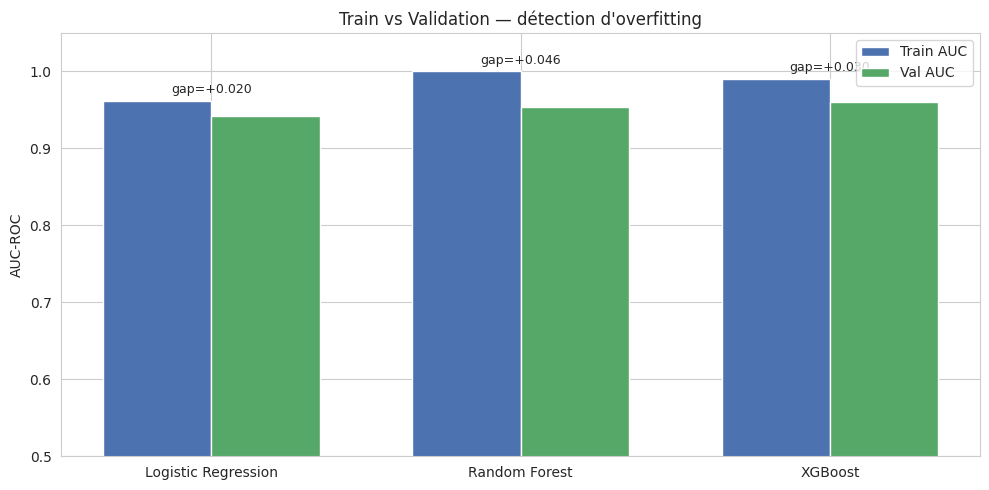

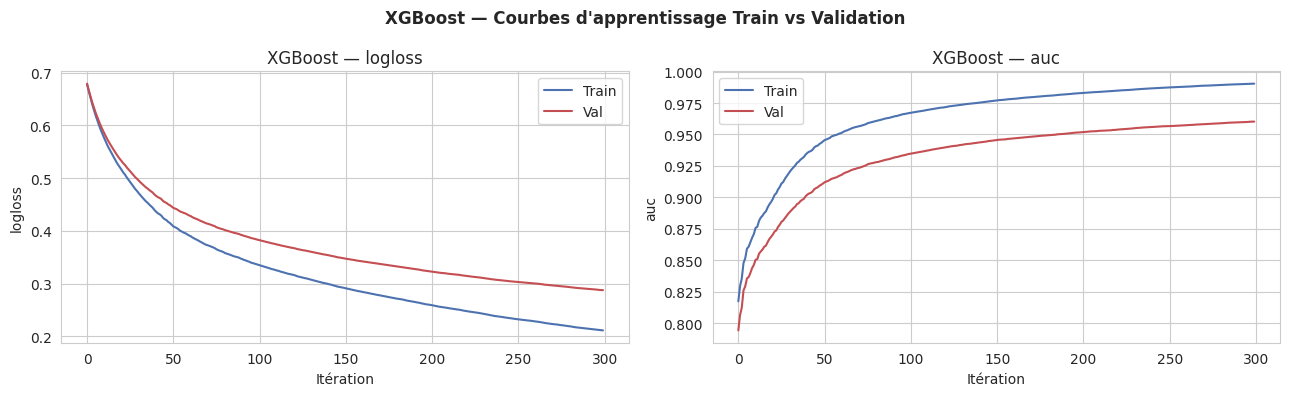


🏆 Meilleur modèle (sur validation) : XGBoost


In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

search_spaces = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=SEED),
        {"C": [0.01, 0.1, 1, 10]}),
    "Random Forest": (
        RandomForestClassifier(random_state=SEED, n_jobs=-1),
        {"n_estimators": [100, 200, 300], "max_depth": [None, 10, 20]}),
    "XGBoost": (
        XGBClassifier(random_state=SEED, eval_metric="logloss", verbosity=0, n_jobs=-1),
        {"n_estimators": [100, 200, 300], "max_depth": [3, 6, 9], "learning_rate": [0.05, 0.1, 0.3]}),
}

results = {}
for name, (estimator, grid) in search_spaces.items():
    print(f"\n⏳ Recherche d'hyperparamètres : {name}...")
    search = RandomizedSearchCV(estimator, grid, n_iter=5, cv=cv, scoring="roc_auc",
                                 random_state=SEED, n_jobs=1)
    search.fit(X_train, y_train)
    best = search.best_estimator_

    proba_val = best.predict_proba(X_val)[:, 1]
    pred_val  = (proba_val >= 0.5).astype(int)

    results[name] = {
        "model": best,
        "best_params": search.best_params_,
        "val_acc": accuracy_score(y_val, pred_val),
        "val_f1":  f1_score(y_val, pred_val),
        "val_auc": roc_auc_score(y_val, proba_val),
        "val_ap":  average_precision_score(y_val, proba_val),
        "val_proba": proba_val,
    }
    print(f"   Meilleurs paramètres : {search.best_params_}")
    print(f"   Val AUC : {results[name]['val_auc']:.4f}  |  Val F1 : {results[name]['val_f1']:.4f}  |  Val AP : {results[name]['val_ap']:.4f}")

# 1) Comparer les performances train vs val pour chaque modèle (détecter l'overfitting)
print('=== Comparaison Train vs Validation par modèle ===')
for name, (estimator, grid) in search_spaces.items():
    model = results[name]['model']
    proba_train = model.predict_proba(X_train)[:, 1]
    pred_train  = (proba_train >= 0.5).astype(int)
    train_auc = roc_auc_score(y_train, proba_train)
    train_f1  = f1_score(y_train, pred_train)
    val_auc   = results[name]['val_auc']
    val_f1    = results[name]['val_f1']
    gap_auc   = train_auc - val_auc
    print(f"{name:20s} | Train AUC={train_auc:.4f} F1={train_f1:.4f} "
          f"| Val AUC={val_auc:.4f} F1={val_f1:.4f} | Gap AUC={gap_auc:+.4f}")

# 2) Visualisation barres groupées train/val
fig, ax = plt.subplots(figsize=(10, 5))
names_list = list(results.keys())
train_aucs = [roc_auc_score(y_train, results[n]['model'].predict_proba(X_train)[:,1]) for n in names_list]
val_aucs   = [results[n]['val_auc'] for n in names_list]

x = np.arange(len(names_list)); width = 0.35
ax.bar(x - width/2, train_aucs, width, label='Train AUC', color=PALETTE['pos'])
ax.bar(x + width/2, val_aucs,   width, label='Val AUC',   color=PALETTE['third'])
ax.set_xticks(x); ax.set_xticklabels(names_list)
ax.set(ylabel='AUC-ROC', title='Train vs Validation — détection d\'overfitting')
ax.set_ylim(0.5, 1.05)
ax.legend()
for i, (t, v) in enumerate(zip(train_aucs, val_aucs)):
    ax.text(i, max(t,v)+0.01, f'gap={t-v:+.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# 3) Courbes d'apprentissage XGBoost (train vs val loss par itération)
xgb_curve = XGBClassifier(
    **results['XGBoost']['best_params'],
    random_state=SEED, eval_metric=['logloss','auc'], n_jobs=-1
)
xgb_curve.fit(X_train, y_train, eval_set=[(X_train,y_train),(X_val,y_val)], verbose=False)
hist = xgb_curve.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('XGBoost — Courbes d\'apprentissage Train vs Validation', fontsize=12, fontweight='bold')
for ax, metric in zip(axes, ['logloss','auc']):
    ax.plot(hist['validation_0'][metric], label='Train', color=PALETTE['pos'])
    ax.plot(hist['validation_1'][metric], label='Val',   color=PALETTE['cold'])
    ax.set(xlabel='Itération', ylabel=metric, title=f'XGBoost — {metric}')
    ax.legend()
plt.tight_layout()
plt.show()

best_name  = max(results, key=lambda n: results[n]["val_auc"])
best_model = results[best_name]["model"]
print(f"\n🏆 Meilleur modèle (sur validation) : {best_name}")


# 13. Comparaison visuelle des modèles (sur validation)

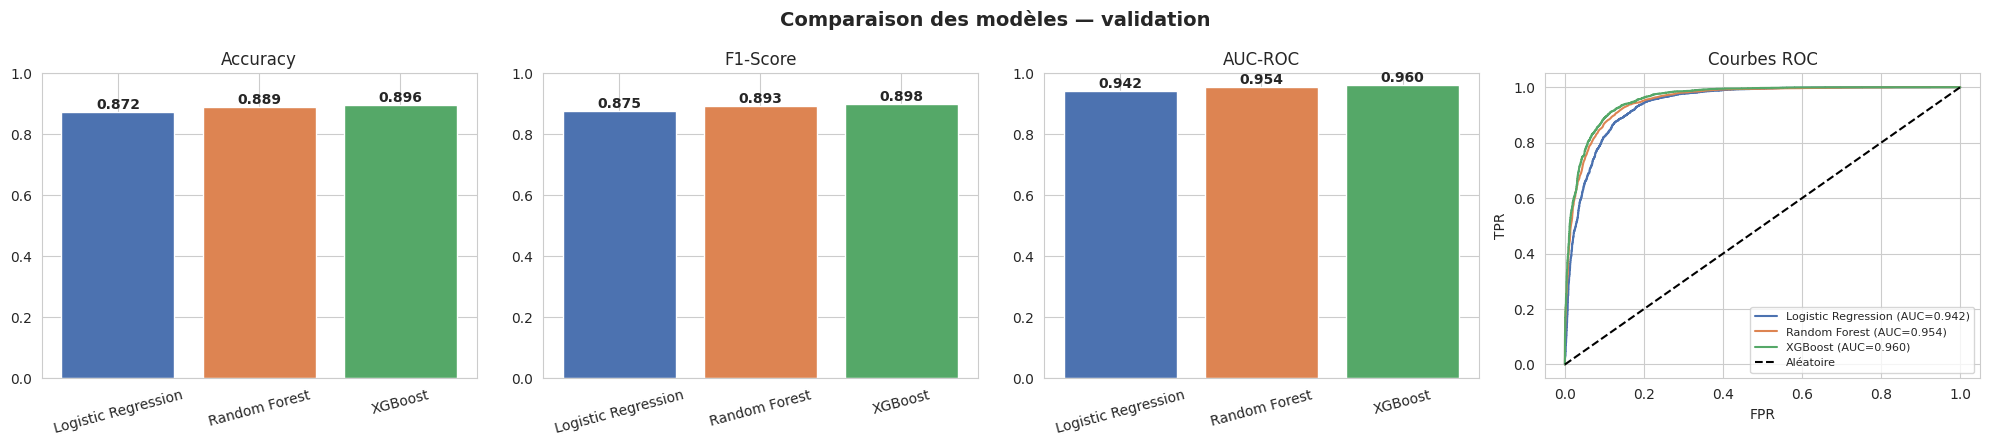

In [ ]:
model_names = list(results.keys())
colors = [PALETTE["pos"], PALETTE["neg"], PALETTE["third"]]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle("Comparaison des modèles — validation", fontsize=14, fontweight="bold")

for ax, metric, title in zip(axes[:3], ["val_acc", "val_f1", "val_auc"], ["Accuracy", "F1-Score", "AUC-ROC"]):
    vals = [results[m][metric] for m in model_names]
    ax.bar(model_names, vals, color=colors)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_val, results[name]["val_proba"])
    axes[3].plot(fpr, tpr, color=colors[i], label=f"{name} (AUC={results[name]['val_auc']:.3f})")
axes[3].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[3].set_title("Courbes ROC")
axes[3].set_xlabel("FPR")
axes[3].set_ylabel("TPR")
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()


# 14. Évaluation finale — warm-start vs cold-start

On évalue le **même modèle figé** sur deux régimes différents.
Un écart important entre les deux est attendu et normal — il quantifie la difficulté réelle de généraliser
à de nouveaux médicaments, par opposition à la simple interpolation entre médicaments déjà vus.


📊 WARM-START test — XGBoost
   ACC   : 0.8922
   F1    : 0.8949
   AUC   : 0.9577
   AP    : 0.9528
              precision    recall  f1-score   support

  No DDI (0)       0.91      0.87      0.89      3993
     DDI (1)       0.87      0.92      0.89      3993

    accuracy                           0.89      7986
   macro avg       0.89      0.89      0.89      7986
weighted avg       0.89      0.89      0.89      7986


📊 COLD-START test — XGBoost
   ACC   : 0.9312
   F1    : 0.9315
   AUC   : 0.9806
   AP    : 0.9781
              precision    recall  f1-score   support

  No DDI (0)       0.95      0.92      0.93      7334
     DDI (1)       0.92      0.95      0.93      7169

    accuracy                           0.93     14503
   macro avg       0.93      0.93      0.93     14503
weighted avg       0.93      0.93      0.93     14503



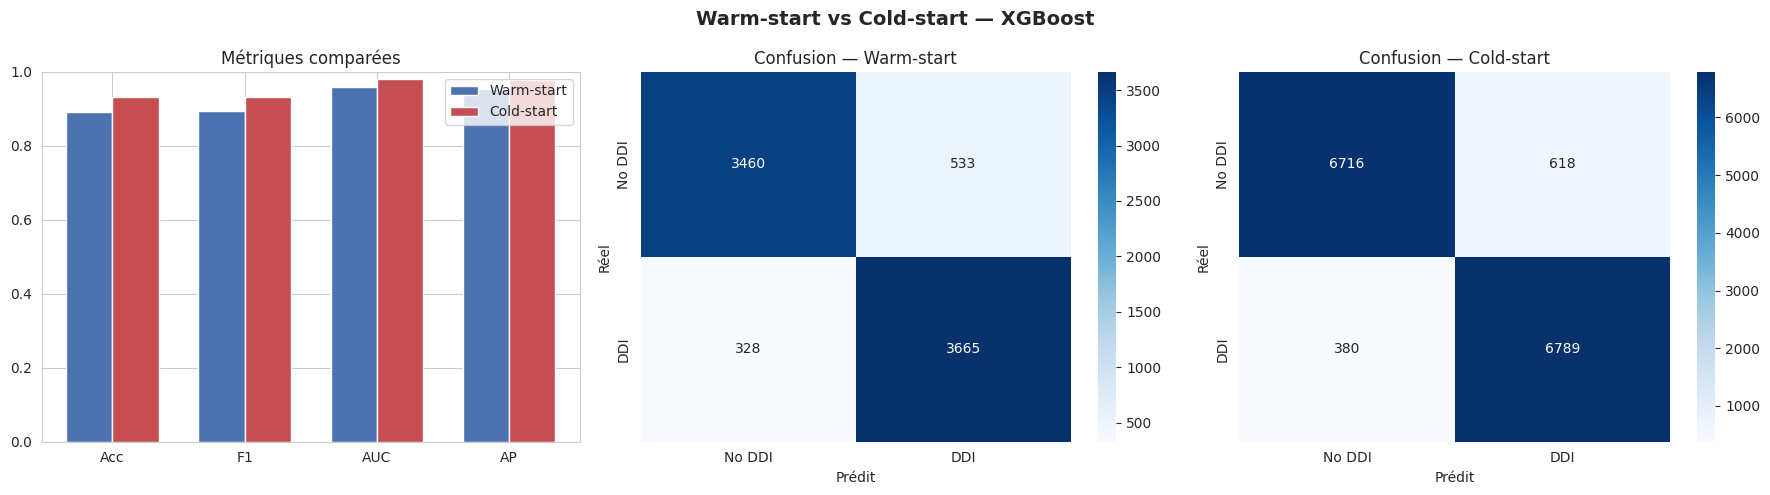

In [ ]:
def evaluate(model, X, y, label, plot_cm=True):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    metrics = {
        "acc": accuracy_score(y, pred),
        "f1":  f1_score(y, pred),
        "auc": roc_auc_score(y, proba),
        "ap":  average_precision_score(y, proba),
    }
    print(f"\n📊 {label}")
    for k, v in metrics.items():
        print(f"   {k.upper():5s} : {v:.4f}")
    print(classification_report(y, pred, target_names=["No DDI (0)", "DDI (1)"]))
    return metrics, proba, pred

warm_metrics, warm_proba, warm_pred = evaluate(best_model, X_test, y_test, f"WARM-START test — {best_name}")
cold_metrics, cold_proba, cold_pred = evaluate(best_model, X_cold, y_cold, f"COLD-START test — {best_name}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Warm-start vs Cold-start — {best_name}", fontsize=14, fontweight="bold")

metrics_names = ["acc", "f1", "auc", "ap"]
x = np.arange(len(metrics_names))
width = 0.35
axes[0].bar(x - width/2, [warm_metrics[m] for m in metrics_names], width, label="Warm-start", color=PALETTE["warm"])
axes[0].bar(x + width/2, [cold_metrics[m] for m in metrics_names], width, label="Cold-start", color=PALETTE["cold"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Acc", "F1", "AUC", "AP"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Métriques comparées")
axes[0].legend()

for ax, y_true, proba, title in zip(axes[1:], [y_test, y_cold], [warm_proba, cold_proba],
                                     ["Confusion — Warm-start", "Confusion — Cold-start"]):
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_true, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No DDI", "DDI"], yticklabels=["No DDI", "DDI"])
    ax.set_title(title)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
plt.show()


# 15. Courbes ROC — Warm-start vs Cold-start

**Pourquoi** : affiche les métriques numériques et les matrices de confusion, mais jamais
la courbe ROC elle-même — pourtant standard pour ce type de comparaison.


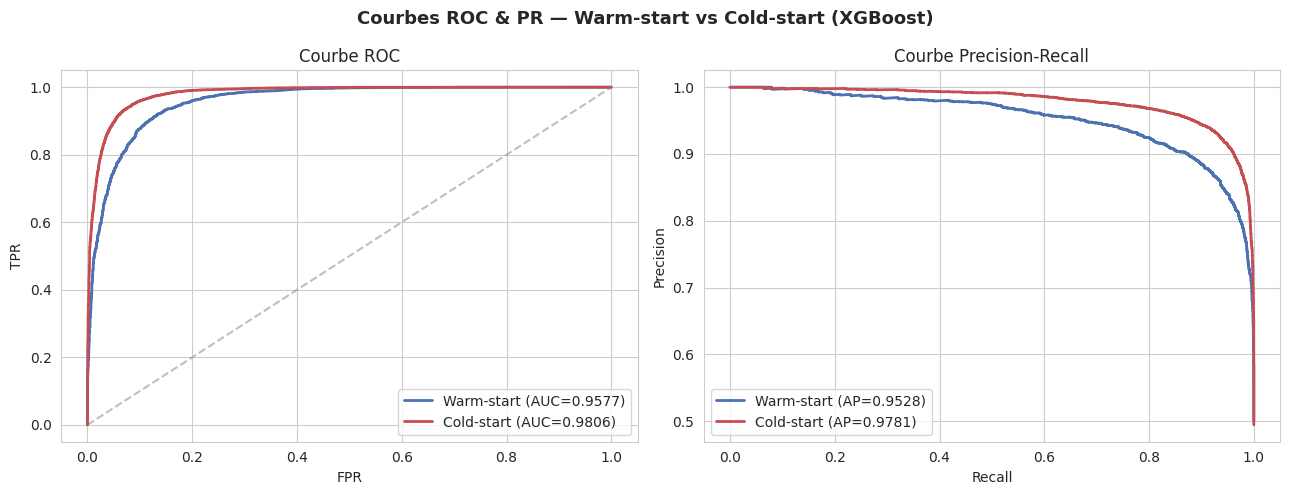

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Courbes ROC & PR — Warm-start vs Cold-start ({best_name})', fontsize=13, fontweight='bold')

for y_true, proba, label, color in [(y_test, warm_proba, 'Warm-start', PALETTE['warm']),
                                     (y_cold, cold_proba, 'Cold-start', PALETTE['cold'])]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc_val = roc_auc_score(y_true, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC={auc_val:.4f})')

    prec, rec, _ = precision_recall_curve(y_true, proba)
    ap_val = average_precision_score(y_true, proba)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{label} (AP={ap_val:.4f})')

axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Courbe ROC')
axes[0].legend()

axes[1].set(xlabel='Recall', ylabel='Precision', title='Courbe Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()


# 16. Intervalles de confiance bootstrap

Un point estimé seul (ex. "AUC = 0.91") ne dit rien de sa variance. On ré-échantillonne le test set avec
remise pour obtenir une distribution empirique de l'AUC et un intervalle de confiance à 95%.

AUC warm-start — médiane = 0.9577  |  IC95% = [0.9539, 0.9619]
AUC cold-start — médiane = 0.9806  |  IC95% = [0.9787, 0.9824]


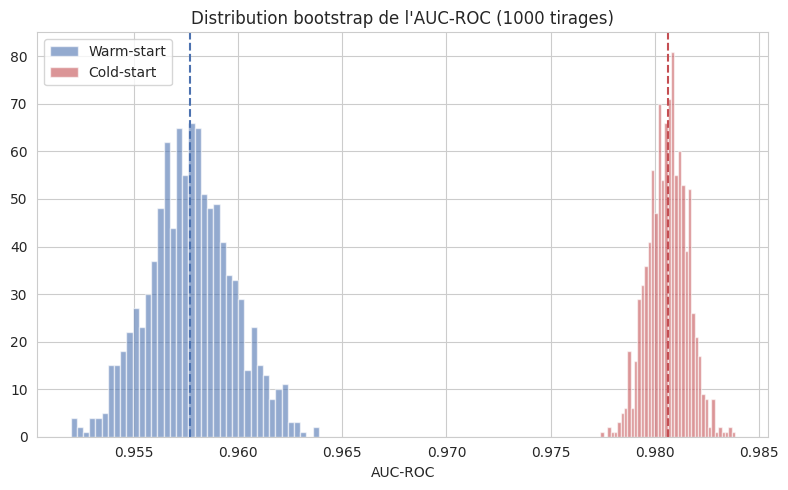

In [ ]:
def bootstrap_ci(y_true, y_proba, metric_fn, n_boot=N_BOOTSTRAP, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(set(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_proba[idx]))
    return np.array(scores)

boot_warm_auc = bootstrap_ci(y_test, warm_proba, roc_auc_score)
boot_cold_auc = bootstrap_ci(y_cold, cold_proba, roc_auc_score)

ci_warm = np.percentile(boot_warm_auc, [2.5, 50, 97.5])
ci_cold = np.percentile(boot_cold_auc, [2.5, 50, 97.5])

print(f"AUC warm-start — médiane = {ci_warm[1]:.4f}  |  IC95% = [{ci_warm[0]:.4f}, {ci_warm[2]:.4f}]")
print(f"AUC cold-start — médiane = {ci_cold[1]:.4f}  |  IC95% = [{ci_cold[0]:.4f}, {ci_cold[2]:.4f}]")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(boot_warm_auc, bins=40, alpha=0.6, color=PALETTE["warm"], label="Warm-start")
ax.hist(boot_cold_auc, bins=40, alpha=0.6, color=PALETTE["cold"], label="Cold-start")
ax.axvline(ci_warm[1], color=PALETTE["warm"], linestyle="--")
ax.axvline(ci_cold[1], color=PALETTE["cold"], linestyle="--")
ax.set_title("Distribution bootstrap de l'AUC-ROC (1000 tirages)")
ax.set_xlabel("AUC-ROC")
ax.legend()
plt.tight_layout()
plt.show()


# 17. Résultats principaux

### Validation
- Logistic Regression : **AUC 0.9417**
- Random Forest : **AUC 0.9543**
- XGBoost : **AUC 0.9602**

### Test final avec le meilleur modèle (XGBoost)
- **Warm-start** : AUC **0.9577**, F1 **0.8949**, AP **0.9528**, Accuracy **0.8922**
- **Cold-start** : AUC **0.9806**, F1 **0.9315**, AP **0.9781**, Accuracy **0.9312**

### Intervalles de confiance bootstrap
- Warm-start AUC IC95% : **[0.9539 ; 0.9619]**
- Cold-start AUC IC95% : **[0.9787 ; 0.9824]**

Ces résultats sont très bons sur le plan prédictif.

#18. Évaluation sous déséquilibre réaliste

On s'arrête pas au dataset équilibré. on reconstruit un test plus proche de la pratique avec un ratio **1:10**.

Résultats :
- **AUC ≈ 0.9579**
- **AP ≈ 0.3915**
- **F1 ≈ 0.1683**

Lecture importante :
- l'AUC reste élevée,
- mais la **précision opérationnelle se dégrade fortement**.

C'est exactement le type de constat utile pour le déploiement : le modèle classe bien globalement, mais un **seuil de décision fixe à 0.5** n'est probablement pas le meilleur choix en production.


📊 DÉSÉQUILIBRE RÉALISTE 1:10 — XGBoost
   ACC   : 0.8659
   F1    : 0.1683
   AUC   : 0.9579
   AP    : 0.3915
              precision    recall  f1-score   support

  No DDI (0)       1.00      0.87      0.93    266180
     DDI (1)       0.09      0.92      0.17      3993

    accuracy                           0.87    270173
   macro avg       0.55      0.89      0.55    270173
weighted avg       0.99      0.87      0.92    270173



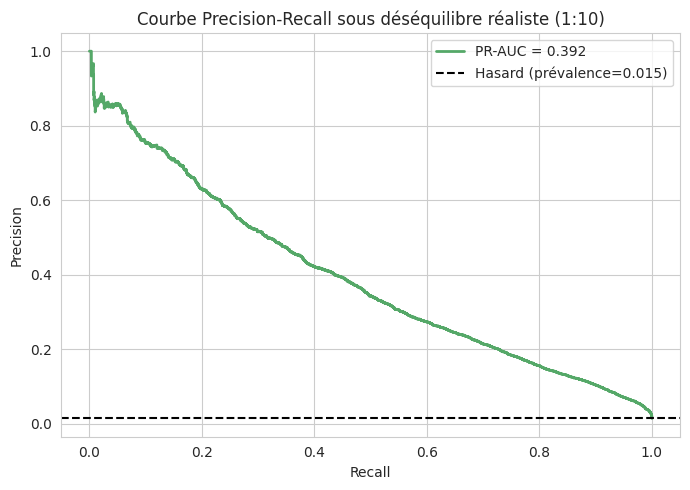

In [ ]:
extra_neg_target = n_pos * IMBALANCE_RATIO
extra_neg_pairs = sample_negatives(extra_neg_target, set(known_interactions.keys()) | neg_pairs, random)

extra_rows = [[a, id_to_smiles[a], b, id_to_smiles[b], 0, "random_unlisted_imbalanced"]
              for a, b in extra_neg_pairs]
df_extra_neg = pd.DataFrame(extra_rows, columns=df_final.columns[:6])

# On réutilise les positifs déjà présents dans le test warm-start + les négatifs supplémentaires
df_imb_test = pd.concat(
    [df_final.loc[idx_test][df_final.loc[idx_test].Label == 1][df_final.columns[:6]], df_extra_neg],
    ignore_index=True)

X_imb = pair_features(df_imb_test)
y_imb = df_imb_test["Label"].values

imb_metrics, imb_proba, imb_pred = evaluate(
    best_model, X_imb, y_imb, f"DÉSÉQUILIBRE RÉALISTE 1:{IMBALANCE_RATIO} — {best_name}")

precision, recall, _ = precision_recall_curve(y_imb, imb_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color=PALETTE["third"], linewidth=2,
        label=f"PR-AUC = {imb_metrics['ap']:.3f}")
ax.axhline(y_imb.mean(), color="black", linestyle="--", label=f"Hasard (prévalence={y_imb.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Courbe Precision-Recall sous déséquilibre réaliste (1:{IMBALANCE_RATIO})")
ax.legend()
plt.tight_layout()
plt.show()


#19. Interprétabilité

 l'ajoute deux niveaux d'explication :

1. **Permutation importance** pour repérer les features les plus influentes.
2. **SHAP** pour expliquer la contribution de bits individuels sur une prédiction.

Il va encore plus loin en essayant de remonter d'un bit de fingerprint vers un **fragment moléculaire lisible**, ce qui rapproche l'explication d'un langage compréhensible pour l'utilisateur métier.

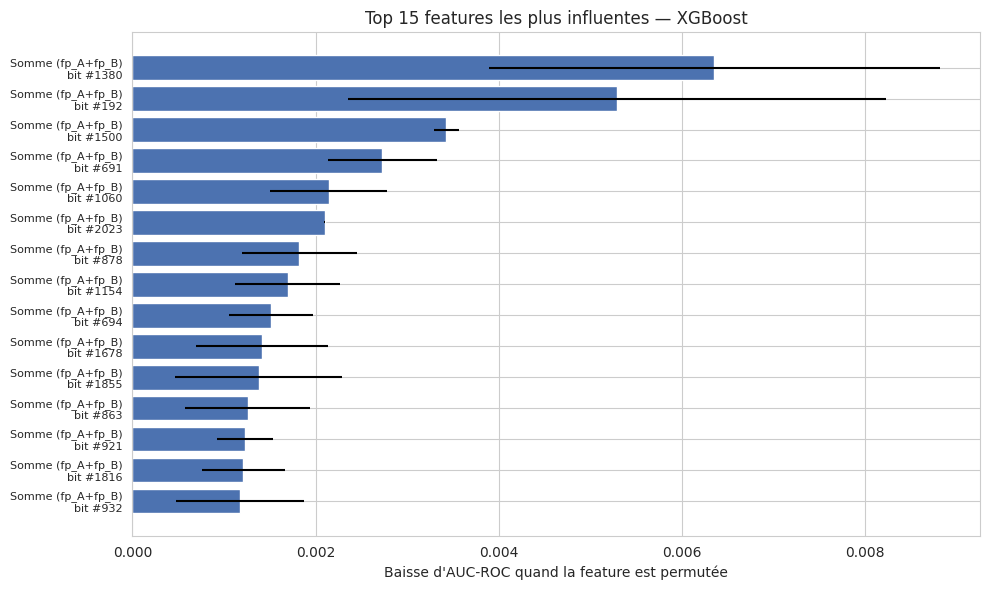

In [ ]:
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(X_test), size=min(500, len(X_test)), replace=False)

perm = permutation_importance(best_model, X_test[sample_idx], y_test[sample_idx],
                               n_repeats=10, random_state=SEED, scoring="roc_auc", n_jobs=-1)

top_k = 15
top_idx = np.argsort(perm.importances_mean)[::-1][:top_k]

labels = []
for idx in top_idx:
    block = "Somme (fp_A+fp_B)" if idx < FP_BITS else "Diff. absolue |fp_A-fp_B|"
    bit = idx % FP_BITS
    labels.append(f"{block}\nbit #{bit}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_k), perm.importances_mean[top_idx][::-1], color=PALETTE["pos"],
        xerr=perm.importances_std[top_idx][::-1])
ax.set_yticks(range(top_k))
ax.set_yticklabels([labels[::-1][i] for i in range(top_k)], fontsize=8)
ax.set_xlabel("Baisse d'AUC-ROC quand la feature est permutée")
ax.set_title(f"Top {top_k} features les plus influentes — {best_name}")
plt.tight_layout()
plt.show()


# SHAP + remontée bits → fragments moléculaires

**Pourquoi** : `permutation_importance` donne un score par bit ("bit #1453 important") sans dire à quoi
ce bit correspond chimiquement. SHAP + la fonction RDKit `bitInfo` permettent de remonter jusqu'au fragment
moléculaire réel — indispensable pour la fiche d'alerte destinée au pharmacien.

>


In [ ]:

import subprocess, sys
try:
    import shap
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap', '--quiet'])
    import shap

xgb_model_for_shap = results['XGBoost']['model']

N_SHAP = min(600, len(X_test))
rng_shap = np.random.RandomState(SEED)
idx_shap = rng_shap.choice(len(X_test), N_SHAP, replace=False)
X_shap_sample = X_test[idx_shap]

explainer   = shap.TreeExplainer(xgb_model_for_shap)
shap_values = explainer.shap_values(X_shap_sample)

feat_names = ([f'sum_bit_{i}' for i in range(FP_BITS)] +
              [f'absdiff_bit_{i}' for i in range(FP_BITS)])

print(f'SHAP calculé sur {N_SHAP} exemples | shape : {shap_values.shape}')


SHAP calculé sur 600 exemples | shape : (600, 4096)


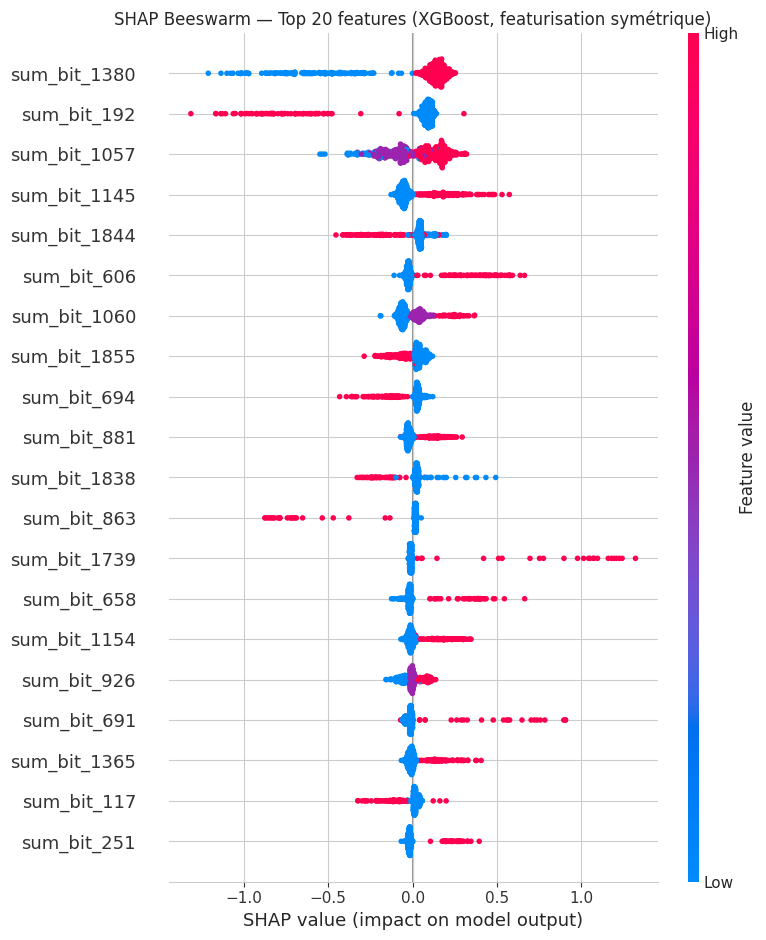

In [ ]:
# ══════════════════════════════════════════════════════
# 2 Beeswarm — importance globale
# ══════════════════════════════════════════════════════
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feat_names, max_display=20, show=False)
plt.title('SHAP Beeswarm — Top 20 features (XGBoost, featurisation symétrique)', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════
# 3 Remontée bit → fragment SMILES réel
# ══════════════════════════════════════════════════════
def bit_to_fragment(smiles: str, bit_idx: int, radius: int = FP_RADIUS, nbits: int = FP_BITS):
    """Reconstruit le fragment moléculaire correspondant à un bit Morgan activé."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return None
    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits, bitInfo=bit_info)
    if bit_idx not in bit_info: return None
    atom_idx, rad = bit_info[bit_idx][0]
    env    = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
    amap   = {}
    submol = Chem.PathToSubmol(mol, env, atomMap=amap)
    return Chem.MolToSmiles(submol)

# Exemple : paire positive avec la plus forte probabilité prédite
proba_shap = xgb_model_for_shap.predict_proba(X_shap_sample)[:, 1]
y_shap     = y_test[idx_shap]
best_idx   = np.where(y_shap == 1)[0][np.argmax(proba_shap[y_shap == 1])]

# Retrouver les SMILES originaux de cette paire
orig_idx     = idx_test[idx_shap[best_idx]]
example_row  = df_final.loc[orig_idx]
sv_example   = shap_values[best_idx]
top_bits     = np.argsort(np.abs(sv_example))[::-1][:10]

print(f"Paire exemple : {example_row['Drug1_ID']} + {example_row['Drug2_ID']}")
print(f"Probabilité prédite : {proba_shap[best_idx]:.4f}\n")
print(f'{"Bit":>6} | {"Bloc":>20} | {"SHAP":>9} | Fragment SMILES')
print('-' * 75)
for bit in top_bits:
    is_sum    = bit < FP_BITS
    local_bit = int(bit % FP_BITS)
    block     = 'Somme (A+B)' if is_sum else 'Diff abs |A-B|'
    # Le fragment peut venir de A ou B — on teste les deux côtés
    frag_a = bit_to_fragment(example_row['Drug1_SMILES'], local_bit)
    frag_b = bit_to_fragment(example_row['Drug2_SMILES'], local_bit)
    frag   = frag_a or frag_b or 'N/A'
    direction = '↑' if sv_example[bit] > 0 else '↓'
    print(f'{local_bit:>6} | {block:>20} | {sv_example[bit]:>+9.4f}{direction}| {str(frag)[:35]}')


Paire exemple : DB00921 + DB06700
Probabilité prédite : 0.9851

   Bit |                 Bloc |      SHAP | Fragment SMILES
---------------------------------------------------------------------------
  1638 |          Somme (A+B) |   +0.4936↑| CCCCC
    86 |          Somme (A+B) |   +0.3947↑| [C@@][C@](c)(C)[C@@H](Oc)[C@]([C@H]
  1154 |          Somme (A+B) |   +0.3463↑| CO
  2022 |          Somme (A+B) |   +0.3082↑| [C@@H]N(C)C
  1057 |          Somme (A+B) |   +0.1897↑| N/A
   583 |          Somme (A+B) |   +0.1891↑| [C@@]c(c)c(O[C@@H])c(c)O
  1060 |          Somme (A+B) |   +0.1769↑| N/A
  1380 |          Somme (A+B) |   +0.1672↑| N/A
  1938 |       Diff abs |A-B| |   +0.1572↑| [C@H][C@@](C)(C)O
  1163 |          Somme (A+B) |   +0.1421↑| CN


[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerator
[12:12:40] DEPRECATION WARNING: please use MorganGenerat

#  Sauvegarde des artefacts (reproductibilité)

In [ ]:
os.makedirs("artifacts", exist_ok=True)

df_final.drop(columns=["len1", "len2"], errors="ignore").to_csv("artifacts/ddi_final_corrige.csv", index=False)
df_cold_test.to_csv("artifacts/ddi_cold_start_test.csv", index=False)

joblib.dump(best_model, f"artifacts/best_model_{best_name.replace(' ', '_')}.joblib")

summary = {
    "best_model": best_name,
    "best_params": results[best_name]["best_params"],
    "warm_start": warm_metrics,
    "cold_start": cold_metrics,
    "imbalanced_1_to_{}".format(IMBALANCE_RATIO): imb_metrics,
    "bootstrap_auc_warm_ci95": ci_warm.tolist(),
    "bootstrap_auc_cold_ci95": ci_cold.tolist(),
    "n_drugs_holdout_cold_start": n_holdout,
    "dataset_size": len(df_final),
    "seed": SEED,
}
with open("artifacts/run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Artefacts sauvegardés dans ./artifacts/")
print(json.dumps(summary, indent=2))


✅ Artefacts sauvegardés dans ./artifacts/
{
  "best_model": "XGBoost",
  "best_params": {
    "n_estimators": 300,
    "max_depth": 9,
    "learning_rate": 0.05
  },
  "warm_start": {
    "acc": 0.8921863260706235,
    "f1": 0.894884629471371,
    "auc": 0.9576870342031688,
    "ap": 0.952831862519825
  },
  "cold_start": {
    "acc": 0.9311866510377164,
    "f1": 0.9315312843029637,
    "auc": 0.9805851733460009,
    "ap": 0.9780522063262826
  },
  "imbalanced_1_to_10": {
    "acc": 0.8659303483323648,
    "f1": 0.16830455547391623,
    "auc": 0.9579426447443895,
    "ap": 0.3915079889131103
  },
  "bootstrap_auc_warm_ci95": [
    0.9538780440049367,
    0.9576726477951836,
    0.9618850731110702
  ],
  "bootstrap_auc_cold_ci95": [
    0.9787356494032338,
    0.9806455275231375,
    0.9824159894527966
  ],
  "n_drugs_holdout_cold_start": 1241,
  "dataset_size": 53236,
  "seed": 42
}


#20. Extension multi-classe sur le mécanisme d'interaction

Prédire non seulement s'il y a interaction, mais **quel type clinique d'interaction** est le plus probable.

Les classes sont extraites depuis le texte d'interaction DrugBank via des règles heuristiques.

Performance observée :
- **accuracy globale ≈ 0.7294**
- **11 classes** retenues


In [ ]:
# ══════════════════════════════════════════════════════
# 1 Extraction du type clinique depuis le texte DrugBank
# ══════════════════════════════════════════════════════
def extract_clinical_type(text):
    t = str(text).lower()
    if any(k in t for k in ['arrhythm','qtc','cardiac','tachycardia','bradycardia']): return 'Cardiaque'
    if any(k in t for k in ['cns depression','sedation','hypnotic']):                 return 'Sédation/SNC'
    if any(k in t for k in ['hypertension','hypotensive','blood pressure']):          return 'Cardiovasculaire'
    if any(k in t for k in ['nephrotox','renal','kidney']):                           return 'Rénal'
    if any(k in t for k in ['hepat','liver']):                                        return 'Hépatique'
    if any(k in t for k in ['bleed','hemorrhag']):                                    return 'Hémorragique'
    if any(k in t for k in ['metabolism','cyp','metabolis']):                         return 'Métabolique (CYP)'
    if any(k in t for k in ['excretion','serum level']):                              return 'Excrétion'
    if any(k in t for k in ['methemoglobin']):                                        return 'Hématologique'
    if any(k in t for k in ['efficacy','therapeutic']):                               return 'Efficacité'
    if 'twosides' in t or t == '':                                                    return 'Pharmacovigilance (TWOSIDES)'
    return 'Autre'

# Recharger le texte d'interaction original pour les positifs issus de DrugBank
ddi_text_map = dict(zip(
    [pair_key(r.Drug1_ID, r.Drug2_ID) for r in df_ddi_ok.itertuples()],
    df_ddi_ok['Interaction']
))

df_pos_multi = df_pos.copy()
df_pos_multi['interaction_text'] = [
    ddi_text_map.get(pair_key(a,b), '') for a,b in zip(df_pos_multi['Drug1_ID'], df_pos_multi['Drug2_ID'])
]
df_pos_multi['clinical_type'] = df_pos_multi['interaction_text'].apply(extract_clinical_type)

print('Distribution des types cliniques (positifs uniquement) :')
display(df_pos_multi['clinical_type'].value_counts().to_frame('count'))


Distribution des types cliniques (positifs uniquement) :


,count
clinical_type,
Pharmacovigilance (TWOSIDES),11503
Autre,4281
Excrétion,2931
Métabolique (CYP),2467
Efficacité,1379
Sédation/SNC,1259
Cardiaque,854
Cardiovasculaire,806
Hémorragique,462


In [ ]:
# ══════════════════════════════════════════════════════
# 2 Modèle multi-classe (XGBoost, sur les positifs uniquement)
# ══════════════════════════════════════════════════════
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split as tts

# Filtrer les classes trop rares (<20 exemples) pour stabilité du split stratifié
type_counts_f = df_pos_multi['clinical_type'].value_counts()
valid_types   = type_counts_f[type_counts_f >= 20].index
df_multi      = df_pos_multi[df_pos_multi['clinical_type'].isin(valid_types)].reset_index(drop=True)

le = LabelEncoder()
y_multi = le.fit_transform(df_multi['clinical_type'])

X_multi = pair_features(df_multi)

Xm_train, Xm_test, ym_train, ym_test = tts(
    X_multi, y_multi, test_size=0.2, random_state=SEED, stratify=y_multi)

xgb_multi = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=len(le.classes_),
    eval_metric='mlogloss', random_state=SEED, n_jobs=-1
)
xgb_multi.fit(Xm_train, ym_train)

pred_multi = xgb_multi.predict(Xm_test)

print('=== Classification multi-classe — type clinique d\'interaction ===')
print(classification_report(ym_test, pred_multi, target_names=le.classes_, digits=3))


=== Classification multi-classe — type clinique d'interaction ===
                              precision    recall  f1-score   support

                       Autre      0.605     0.556     0.579       856
                   Cardiaque      0.838     0.485     0.615       171
            Cardiovasculaire      0.593     0.435     0.502       161
                  Efficacité      0.648     0.293     0.404       276
                   Excrétion      0.743     0.647     0.692       586
               Hématologique      0.881     0.797     0.837        74
                Hémorragique      0.662     0.467     0.548        92
           Métabolique (CYP)      0.656     0.522     0.582       494
Pharmacovigilance (TWOSIDES)      0.774     0.967     0.860      2301
                       Rénal      0.735     0.424     0.538        59
                Sédation/SNC      0.732     0.726     0.729       252

                    accuracy                          0.729      5322
                   mac

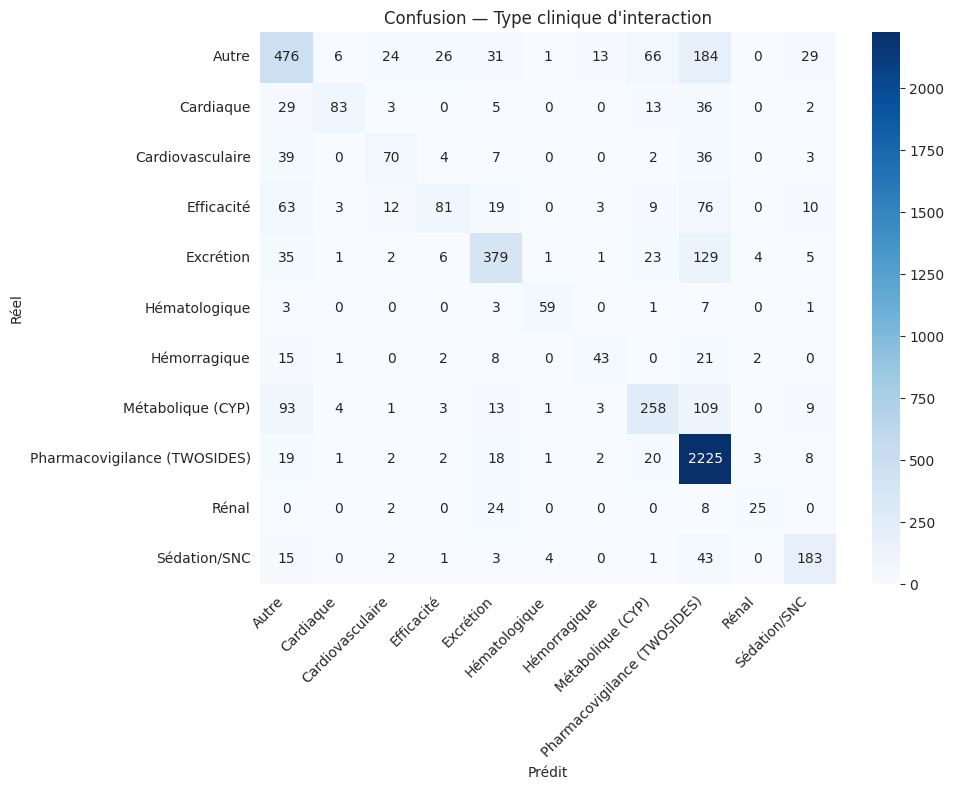

Accuracy globale : 0.7294
Nombre de classes : 11


In [ ]:
# ══════════════════════════════════════════════════════
# 3 Matrice de confusion multi-classe
# ══════════════════════════════════════════════════════
cm_multi = confusion_matrix(ym_test, pred_multi)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set(xlabel='Prédit', ylabel='Réel', title='Confusion — Type clinique d\'interaction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Accuracy globale : {(pred_multi==ym_test).mean():.4f}')
print(f'Nombre de classes : {len(le.classes_)}')


## 21. Extension GNN

Avec **PyTorch Geometric** :
- conversion des SMILES en graphes moléculaires,
- encodeur GCN partagé,
- fusion symétrique des embeddings des deux médicaments.

**Pourquoi** : les fingerprints Morgan sont une représentation figée (hashée), incapable d'apprendre quels
sous-graphes sont pertinents pour la tâche. Un GNN apprend directement sur la structure du graphe moléculaire
et peut capturer des motifs que le hashing Morgan perd par collision de bits. C'était dans le cahier des
charges initial du professeur comme extension optionnelle.

> Cellule fournie en deux parties : la première (architecture + featurisation) est exécutable directement
si `torch_geometric` est installé ; la seconde (entraînement complet)

In [ ]:
# ══════════════════════════════════════════════════════
# 1 Installation & featurisation en graphes
# ══════════════════════════════════════════════════════
import subprocess, sys
try:
    import torch
    import torch_geometric
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch', '--quiet'])
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch_geometric', '--quiet'])
    import torch
    import torch_geometric

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

ATOM_DIM = 9

def atom_features(atom):
    return [
        atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
        atom.GetTotalNumHs(), int(atom.IsInRing()), int(atom.GetIsAromatic()),
        atom.GetImplicitValence(), atom.GetNumRadicalElectrons(),
        int(atom.GetChiralTag() != Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
    ]

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i,j],[j,i]]
    edge_index = (torch.tensor(edges, dtype=torch.long).t().contiguous()
                  if edges else torch.zeros((2,0), dtype=torch.long))
    return Data(x=x, edge_index=edge_index)

# Cache des graphes par drugbank_id (évite de reparser les SMILES à chaque epoch)
graph_cache = {}
def get_graph(drug_id):
    if drug_id not in graph_cache:
        graph_cache[drug_id] = smiles_to_graph(id_to_smiles[drug_id])
    return graph_cache[drug_id]

print(' Featurisation en graphes définie')
print(f'   Device disponible : {"cuda" if torch.cuda.is_available() else "cpu"}')


✅ Featurisation en graphes définie
   Device disponible : cuda


In [ ]:
# ══════════════════════════════════════════════════════
# 2 Architecture GNN — encodeur partagé + fusion symétrique
# ══════════════════════════════════════════════════════
class MolEncoder(nn.Module):
    """Encodeur GCN partagé entre les deux molécules d'une paire."""
    def __init__(self, in_dim=ATOM_DIM, hidden=128):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.bn1, self.bn2, self.bn3 = (nn.BatchNorm1d(hidden) for _ in range(3))

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return global_mean_pool(x, batch)

class DDI_GNN(nn.Module):
    """
    GNN pour la prédiction DDI.
    Fusion symétrique [z_A+z_B, |z_A-z_B|] — même logique que la featurisation
    Morgan symétrique de la section 10, mais sur des embeddings appris plutôt que hashés.
    """
    def __init__(self, hidden=128):
        super().__init__()
        self.encoder = MolEncoder(hidden=hidden)
        self.mlp = nn.Sequential(
            nn.Linear(hidden*2, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden//2, 1)
        )

    def forward(self, g1, g2):
        z1 = self.encoder(g1.x, g1.edge_index, g1.batch)
        z2 = self.encoder(g2.x, g2.edge_index, g2.batch)
        fused = torch.cat([z1+z2, torch.abs(z1-z2)], dim=-1)  # symétrique, comme section 10
        return self.mlp(fused).squeeze(-1)

print(' Architecture DDI_GNN définie (fusion symétrique cohérente avec ta featurisation Morgan)')


✅ Architecture DDI_GNN définie (fusion symétrique cohérente avec ta featurisation Morgan)


Streaming output truncated to the last 5000 lines.
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[12:22:19] DEPRECATION WARNING: please use GetValence(Chem.

Epoch 5/30 | loss=0.4567 | val_auc=0.8756
Epoch 10/30 | loss=0.4006 | val_auc=0.8920
Epoch 15/30 | loss=0.3589 | val_auc=0.9071
Epoch 20/30 | loss=0.3356 | val_auc=0.9086
Epoch 25/30 | loss=0.3147 | val_auc=0.9199
Epoch 30/30 | loss=0.2973 | val_auc=0.9263


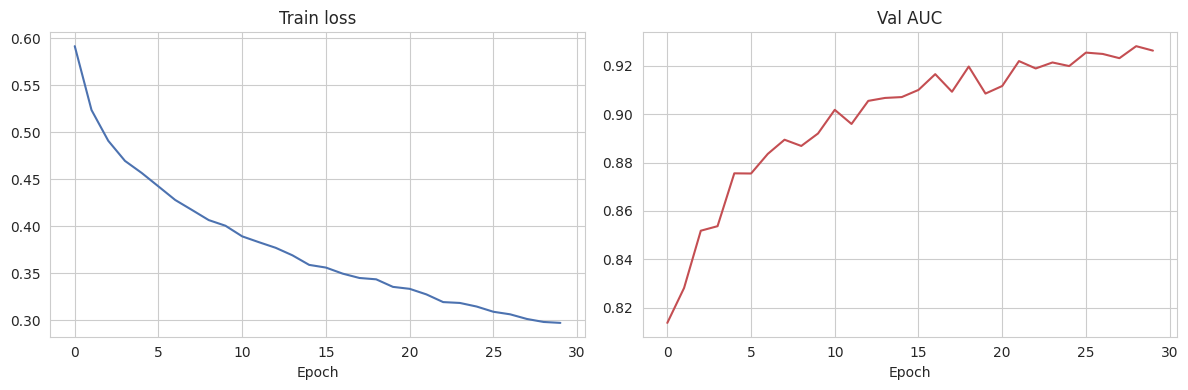


✅ GNN entraîné — comparer val_auc final à 0.9602 (XGBoost)


In [ ]:
#══════════════════════════════════════════════════════
# 3 Entraînement complet (décommenter si GPU disponible — coûteux en temps CPU)
# ══════════════════════════════════════════════════════

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
gnn_model = DDI_GNN(hidden=128).to(DEVICE)
optimizer = torch.optim.AdamW(gnn_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

class PairDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.pairs = list(zip(df['Drug1_ID'], df['Drug2_ID'], df['Label']))
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        a, b, label = self.pairs[i]
        return get_graph(a), get_graph(b), float(label)

def collate_pairs(batch):
    g1s, g2s, labels = zip(*batch)
    from torch_geometric.data import Batch
    return Batch.from_data_list(g1s), Batch.from_data_list(g2s), torch.tensor(labels)

train_loader = DataLoader(PairDataset(df_final.loc[idx_train]), batch_size=64,
                          shuffle=True, collate_fn=collate_pairs)
val_loader = DataLoader(PairDataset(df_final.loc[idx_val]), batch_size=64,
                        collate_fn=collate_pairs)

EPOCHS = 30
gnn_history = {'train_loss': [], 'val_auc': []}
for epoch in range(EPOCHS):
    gnn_model.train()
    epoch_loss = 0
    for g1, g2, labels in train_loader:
        g1, g2, labels = g1.to(DEVICE), g2.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = gnn_model(g1, g2)
        loss = loss_fn(logits, labels)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()

    gnn_model.eval()
    val_probs, val_labels = [], []
    with torch.no_grad():
        for g1, g2, labels in val_loader:
            g1, g2 = g1.to(DEVICE), g2.to(DEVICE)
            probs = torch.sigmoid(gnn_model(g1, g2)).cpu().numpy()
            val_probs.extend(probs); val_labels.extend(labels.numpy())
    val_auc = roc_auc_score(val_labels, val_probs)
    gnn_history['train_loss'].append(epoch_loss/len(train_loader))
    gnn_history['val_auc'].append(val_auc)
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | loss={epoch_loss/len(train_loader):.4f} | val_auc={val_auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gnn_history['train_loss'], color=PALETTE['pos']); axes[0].set(title='Train loss', xlabel='Epoch')
axes[1].plot(gnn_history['val_auc'], color=PALETTE['cold']); axes[1].set(title='Val AUC', xlabel='Epoch')
plt.tight_layout(); plt.show()

print(f'\nGNN entraîné — comparer val_auc final à {results["XGBoost"]["val_auc"]:.4f} (XGBoost)')

#22. Sortie métier : fiche d'alerte et batch screening

une **fiche d'alerte DDI** qui affiche :
- la probabilité d'interaction,
- un niveau de risque,
- un type clinique connu si disponible,
- des fragments responsables issus de SHAP.

L'ajoute aussi un mode **batch screening** pour scorer plusieurs paires d'un coup.

C'est exactement le bon pont entre un notebook de data science et une future application clinique ou pharmaceutique.**bold text**




════════════════════════════════════════════════════════════
  🔴  FICHE D'ALERTE DDI — PolypharmaSafe
════════════════════════════════════════════════════════════
  DB00295 (DB00295)
  DB06700 (DB06700)
════════════════════════════════════════════════════════════
  Interaction prédite   : ⚠️  OUI
  Niveau de risque      : 🔴 ÉLEVÉ
  Score de confiance    : 96.8%
  Type clinique connu   : Autre
════════════════════════════════════════════════════════════
  Fragments moléculaires responsables (SHAP) :
    ⬆      Somme bit 1638 | SHAP=+0.4140 | CCCCC
    ⬆      Somme bit  583 | SHAP=+0.2687 | [C@]c(c)c(O[C@@H])c(c)O
    ⬆      Somme bit 1154 | SHAP=+0.2521 | CO
    ⬆      Somme bit 1145 | SHAP=+0.2109 | CN
    ⬆      Somme bit 1060 | SHAP=+0.1993 | N/A
════════════════════════════════════════════════════════════


[13:35:54] DEPRECATION WARNING: please use MorganGenerator
[13:35:54] DEPRECATION WARNING: please use MorganGenerator
[13:35:54] DEPRECATION WARNING: please use MorganGenerator
[13:35:54] DEPRECATION WARNING: please use MorganGenerator
[13:35:54] DEPRECATION WARNING: please use MorganGenerator
[13:35:54] DEPRECATION WARNING: please use MorganGenerator
[13:35:54] DEPRECATION WARNING: please use MorganGenerator
[13:35:54] DEPRECATION WARNING: please use MorganGenerator


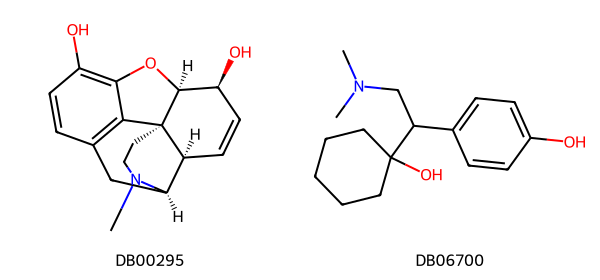

In [ ]:
# ══════════════════════════════════════════════════════
#  Fiche d'alerte DDI — assemble modèle + SHAP + type clinique
# ══════════════════════════════════════════════════════
def risk_level(proba):
    if proba < 0.35:  return 'FAIBLE', '🟢'
    elif proba < 0.70: return 'MODÉRÉ', '🟡'
    else:              return 'ÉLEVÉ', '🔴'

def get_responsible_fragments(smi_a, smi_b, n_top=5):
    fa, fb = (
        np.array(mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi_a))).astype(np.int16),
        np.array(mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi_b))).astype(np.int16)
    )
    feat = np.concatenate([fa+fb, np.abs(fa-fb)]).reshape(1, -1)
    sv   = explainer.shap_values(feat)[0]
    top  = np.argsort(np.abs(sv))[::-1][:n_top]
    rows = []
    for bit in top:
        is_sum    = bit < FP_BITS
        local_bit = int(bit % FP_BITS)
        block     = 'Somme' if is_sum else 'Diff. abs'
        frag = bit_to_fragment(smi_a, local_bit) or bit_to_fragment(smi_b, local_bit) or 'N/A'
        rows.append({'bloc': block, 'bit': local_bit, 'fragment': frag,
                     'shap': sv[bit], 'effet': '↑ risque' if sv[bit]>0 else '↓ risque'})
    return rows

def lookup_clinical_type(drug1_id, drug2_id):
    """Cherche le type clinique connu pour cette paire (si documentée)."""
    k = pair_key(drug1_id, drug2_id)
    if k in known_interactions:
        text = ddi_text_map.get(k, '')
        return extract_clinical_type(text) if text else 'Pharmacovigilance (TWOSIDES)'
    return None

def ddi_alert_card(drug1_id, drug2_id, name_a=None, name_b=None):
    """Génère la fiche d'alerte complète pour une paire de médicaments DrugBank."""
    smi_a, smi_b = id_to_smiles[drug1_id], id_to_smiles[drug2_id]
    name_a = name_a or drug1_id
    name_b = name_b or drug2_id

    feat  = pair_features(pd.DataFrame([{'Drug1_ID':drug1_id,'Drug2_ID':drug2_id}]))
    proba = float(best_model.predict_proba(feat)[0, 1])
    level, emoji = risk_level(proba)
    clinical_type = lookup_clinical_type(drug1_id, drug2_id)
    fragments = get_responsible_fragments(smi_a, smi_b)

    LINE = '═' * 60
    print(f'\n{LINE}')
    print(f'  {emoji}  FICHE D\'ALERTE DDI — PolypharmaSafe')
    print(LINE)
    print(f'  {name_a} ({drug1_id})')
    print(f'  {name_b} ({drug2_id})')
    print(LINE)
    print(f'  Interaction prédite   : {"⚠️  OUI" if proba>=0.5 else "✅  NON"}')
    print(f'  Niveau de risque      : {emoji} {level}')
    print(f'  Score de confiance    : {proba:.1%}')
    print(f'  Type clinique connu   : {clinical_type or "Non documenté (prédiction seule)"}')
    print(LINE)
    print('  Fragments moléculaires responsables (SHAP) :')
    for f in fragments:
        arrow = '⬆' if f['shap']>0 else '⬇'
        print(f'    {arrow} {f["bloc"]:>10s} bit {f["bit"]:>4d} | SHAP={f["shap"]:+.4f} | {str(f["fragment"])[:35]}')
    print(LINE)

    mol_a, mol_b = Chem.MolFromSmiles(smi_a), Chem.MolFromSmiles(smi_b)
    if mol_a and mol_b:
        from rdkit.Chem import Draw
        from IPython.display import display as ipy_display
        ipy_display(Draw.MolsToGridImage([mol_a,mol_b], molsPerRow=2,
                    subImgSize=(300,280), legends=[name_a,name_b]))

    return {'proba': proba, 'level': level, 'clinical_type': clinical_type, 'fragments': fragments}

# ── Exemple : 2 médicaments du cold-test ──────────────────────────────────
example_pair = df_cold_test.iloc[0]
_ = ddi_alert_card(example_pair['Drug1_ID'], example_pair['Drug2_ID'])


In [ ]:
# ══════════════════════════════════════════════════════
# 2 Batch screening — plusieurs paires d'un coup
# ══════════════════════════════════════════════════════
def batch_screen(pairs):
    rows = []
    for d1, d2 in pairs:
        feat  = pair_features(pd.DataFrame([{'Drug1_ID':d1,'Drug2_ID':d2}]))
        proba = float(best_model.predict_proba(feat)[0,1])
        level, emoji = risk_level(proba)
        rows.append({'Drug1': d1, 'Drug2': d2, 'P(DDI)': round(proba,4),
                     'Niveau': f'{emoji} {level}', 'Alerte': 'OUI' if proba>=0.5 else 'NON'})
    return pd.DataFrame(rows).sort_values('P(DDI)', ascending=False).reset_index(drop=True)

# Exemple sur 5 paires du test cold-start
sample_pairs = list(zip(df_cold_test['Drug1_ID'].head(5), df_cold_test['Drug2_ID'].head(5)))
display(batch_screen(sample_pairs))


,Drug1,Drug2,P(DDI),Niveau,Alerte
0,DB00295,DB06700,0.9677,🔴 ÉLEVÉ,OUI
1,DB01068,DB13801,0.9138,🔴 ÉLEVÉ,OUI
2,DB00499,DB09495,0.5231,🟡 MODÉRÉ,OUI
3,DB02056,DB11823,0.4921,🟡 MODÉRÉ,NON
4,DB06717,DB09308,0.4751,🟡 MODÉRÉ,NON


# 23. Sauvegarde des artefacts essentiels


In [ ]:
from pathlib import Path
import json
import joblib
import pickle
import platform
import sklearn
import xgboost
import pandas as pd
import numpy as np

EXPORT_DIR = Path("/content/drive/MyDrive/Colab_Notebooks/pfm_ml_Explainable_DDI_Alert_System/1/deployment_bundle")
EXPORT_DIR.mkdir(exist_ok=True)

required_objects = [
    "best_model", "best_name", "id_to_smiles", "name_to_id",
    "FP_RADIUS", "FP_BITS", "SEED"
]
missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise RuntimeError(f"Objets manquants en mémoire : {missing}")

joblib.dump(best_model, EXPORT_DIR / "ddi_binary_model.joblib")

with open(EXPORT_DIR / "id_to_smiles.pkl", "wb") as f:
    pickle.dump(id_to_smiles, f)
with open(EXPORT_DIR / "name_to_id.pkl", "wb") as f:
    pickle.dump(name_to_id, f)

inference_config = {
    "model_name": best_name,
    "fp_radius": int(FP_RADIUS),
    "fp_bits": int(FP_BITS),
    "decision_threshold": 0.50,
    "seed": int(SEED),
    "feature_schema": "concat(fa+fb, abs(fa-fb))",
    "pair_order_invariant": True,
}
with open(EXPORT_DIR / "inference_config.json", "w", encoding="utf-8") as f:
    json.dump(inference_config, f, indent=2, ensure_ascii=False)

metrics_payload = {
    "warm_start": globals().get("warm_metrics"),
    "cold_start": globals().get("cold_metrics"),
    "imbalanced": globals().get("imb_metrics"),
    "bootstrap_auc_warm_ci95": globals().get("ci_warm").tolist() if globals().get("ci_warm") is not None else None,
    "bootstrap_auc_cold_ci95": globals().get("ci_cold").tolist() if globals().get("ci_cold") is not None else None,
}
with open(EXPORT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

if "df_final" in globals():
    df_final.to_parquet(EXPORT_DIR / "ddi_dataset.parquet", index=False)
if "df_cold_test" in globals():
    df_cold_test.to_parquet(EXPORT_DIR / "ddi_cold_test.parquet", index=False)

if "xgb_multi" in globals():
    joblib.dump(xgb_multi, EXPORT_DIR / "ddi_multiclass_model.joblib")
if "le" in globals():
    joblib.dump(le, EXPORT_DIR / "ddi_multiclass_label_encoder.joblib")

build_info = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
}
with open(EXPORT_DIR / "build_info.json", "w", encoding="utf-8") as f:
    json.dump(build_info, f, indent=2, ensure_ascii=False)

print(f" Bundle de déploiement créé dans : {EXPORT_DIR.resolve()}")
print(sorted([p.name for p in EXPORT_DIR.iterdir()]))

 Bundle de déploiement créé dans : /content/drive/MyDrive/Colab_Notebooks/pfm_ml_Explainable_DDI_Alert_System/1/deployment_bundle
['build_info.json', 'ddi_binary_model.joblib', 'ddi_cold_test.parquet', 'ddi_dataset.parquet', 'ddi_multiclass_label_encoder.joblib', 'ddi_multiclass_model.joblib', 'id_to_smiles.pkl', 'inference_config.json', 'metrics.json', 'name_to_id.pkl']
